# Predict Obesity Level (Multi‑Class Classification)

**Goal:** Predict **obesity level** from lifestyle + physical condition features.

✅ Includes:
- Upload CSV **or** Kaggle API option
- Data cleaning
- EDA (several visual questions)
- Feature engineering (**BMI**)
- Preprocessing (**One‑Hot Encoding + Scaling**)
- Train models: **Naive Bayes, Logistic Regression, SVM (Calibrated for probabilities)**  
  *(Plus a few optional extra models for comparison)*
- Metrics + plots
- Save best model for **Streamlit** + `schema.json` for auto UI inputs

**Dataset:** Kaggle “Obesity Levels”  
Common file: `ObesityDataSet_raw_and_data_sinthetic.csv`  
Target column: `NObeyesdad`

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
# =========================
# 1) Imports
# =========================
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

# Optional extra models (nice for comparison slides)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, VotingClassifier

from sklearn.base import BaseEstimator, TransformerMixin
import joblib

print("Ready ")

Ready 


## 2) Load dataset

### Option A: Upload CSV (recommended)
Upload your dataset CSV from Kaggle.

### Option B: Kaggle API download (optional)
Upload `kaggle.json` and run the Kaggle cell.

In [3]:
# =========================
# Option A: Upload CSV
# =========================
from google.colab import files

uploaded = files.upload()  # choose your dataset .csv
print("Uploaded:", list(uploaded.keys()))

Saving ObesityDataSet_raw_and_data_sinthetic.csv to ObesityDataSet_raw_and_data_sinthetic (2).csv
Uploaded: ['ObesityDataSet_raw_and_data_sinthetic (2).csv']


In [4]:
# =========================
# Option B: Kaggle API download (optional)
# =========================
# Uncomment if you want to download via Kaggle API.
# Steps:
# 1) Create Kaggle API token (kaggle.json)
# 2) Upload it in this cell
# 3) Run this cell

# from google.colab import files
# files.upload()  # upload kaggle.json
# !mkdir -p ~/.kaggle
# !cp kaggle.json ~/.kaggle/
# !chmod 600 ~/.kaggle/kaggle.json
# !pip -q install kaggle
# !kaggle datasets download -d fatemehmehrparvar/obesity-levels -p /content --unzip
# !ls -lah /content

In [5]:
# =========================
# Read CSV (auto-detect first .csv in /content)
# =========================
CSV_PATH = None
for fn in os.listdir("/content"):
    if fn.lower().endswith(".csv"):
        CSV_PATH = os.path.join("/content", fn)
        break

if CSV_PATH is None:
    raise FileNotFoundError("No CSV found in /content. Upload your dataset CSV or download via Kaggle API.")

print("Using CSV:", CSV_PATH)
df = pd.read_csv(CSV_PATH)

print("Shape:", df.shape)
display(df.head())
print("\nColumns:", list(df.columns))

Using CSV: /content/ObesityDataSet_raw_and_data_sinthetic (2).csv
Shape: (2111, 17)


,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
0,21.0,Female,1.62,64.0,no,no,2.0,3.0,no,no,2.0,yes,0.0,1.0,Sometimes,Public_Transportation,Normal_Weight
1,21.0,Female,1.52,56.0,Sometimes,no,3.0,3.0,yes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,23.0,Male,1.80,77.0,Frequently,no,2.0,3.0,no,no,2.0,yes,2.0,1.0,Sometimes,Public_Transportation,Normal_Weight
3,27.0,Male,1.80,87.0,Frequently,no,3.0,3.0,no,no,2.0,no,2.0,0.0,Sometimes,Walking,Overweight_Level_I
4,22.0,Male,1.78,89.8,Sometimes,no,2.0,1.0,no,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II



Columns: ['Age', 'Gender', 'Height', 'Weight', 'CALC', 'FAVC', 'FCVC', 'NCP', 'SCC', 'SMOKE', 'CH2O', 'family_history_with_overweight', 'FAF', 'TUE', 'CAEC', 'MTRANS', 'NObeyesdad']


In [6]:
print(df.shape)

(2111, 17)


# Data Cleaning

In [7]:
# =========================
# 3) Validate columns + basic cleaning
# =========================
TARGET = "NObeyesdad"

if TARGET not in df.columns:
    raise ValueError(f"Target column '{TARGET}' not found. Please check your CSV column names.")

# Drop missing + duplicates (safe default)
df = df.dropna().drop_duplicates()

# Convert target to string labels
df[TARGET] = df[TARGET].astype(str)

print("Rows after cleaning:", len(df))
print("Number of classes:", df[TARGET].nunique())
display(df[TARGET].value_counts())

Rows after cleaning: 2087
Number of classes: 7


,count
NObeyesdad,
Obesity_Type_I,351
Obesity_Type_III,324
Obesity_Type_II,297
Overweight_Level_II,290
Normal_Weight,282
Overweight_Level_I,276
Insufficient_Weight,267


In [8]:
# Quick check for missing values per column
missing = df.isna().sum().sort_values(ascending=False)
display(missing[missing > 0])

,0


# EDA
We’ll answer a few simple questions with quick charts (matplotlib only).

In [9]:
# Helper: safe histogram plot
def hist_plot(series, title, bins=30):
    plt.figure(figsize=(6,4))
    plt.hist(series.dropna().values, bins=bins)
    plt.title(title)
    plt.xlabel(series.name)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

# Helper: bar plot counts
def bar_counts(series, title):
    counts = series.value_counts()
    plt.figure(figsize=(7,4))
    plt.bar(counts.index.astype(str), counts.values)
    plt.title(title)
    plt.xlabel(series.name)
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

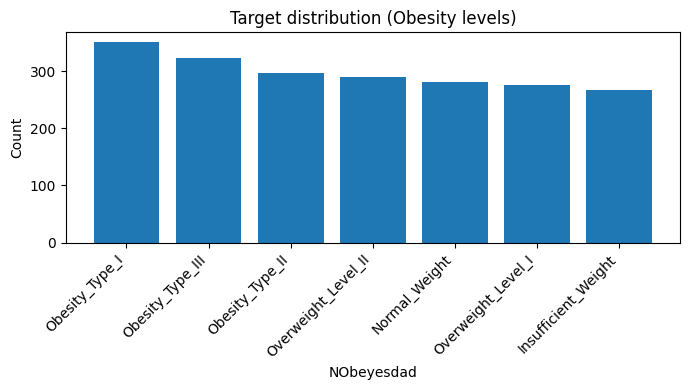

In [10]:
# Target distribution
bar_counts(df[TARGET], "Target distribution (Obesity levels)")

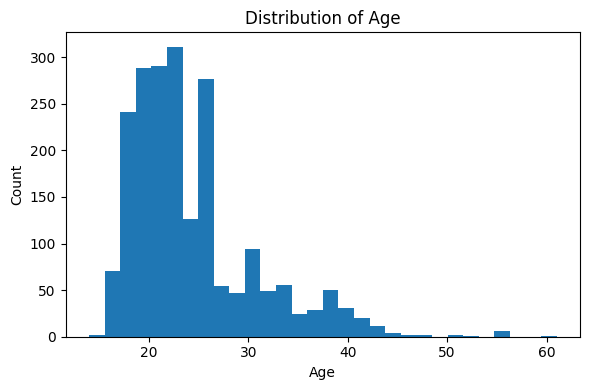

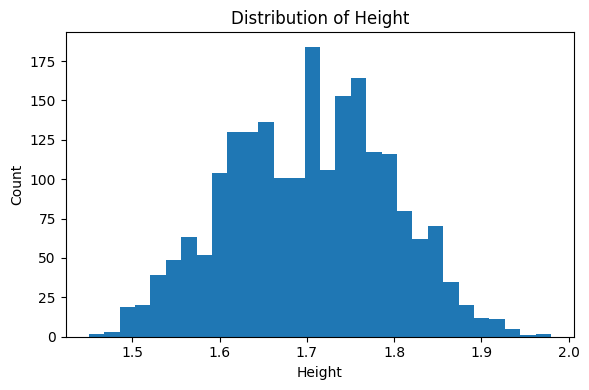

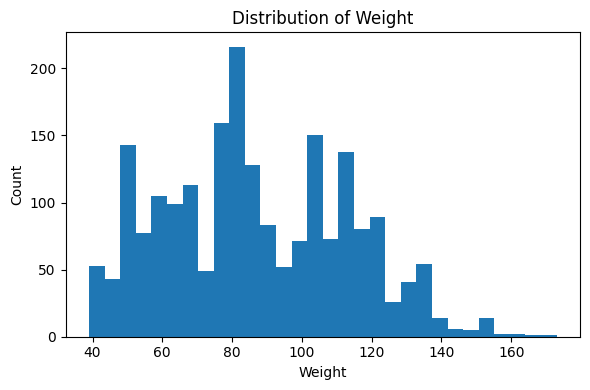

In [11]:
# Numeric feature overview (if present)
for col in ["Age", "Height", "Weight"]:
    if col in df.columns:
        hist_plot(df[col], f"Distribution of {col}")

# How do Age and Weight relate to each other?

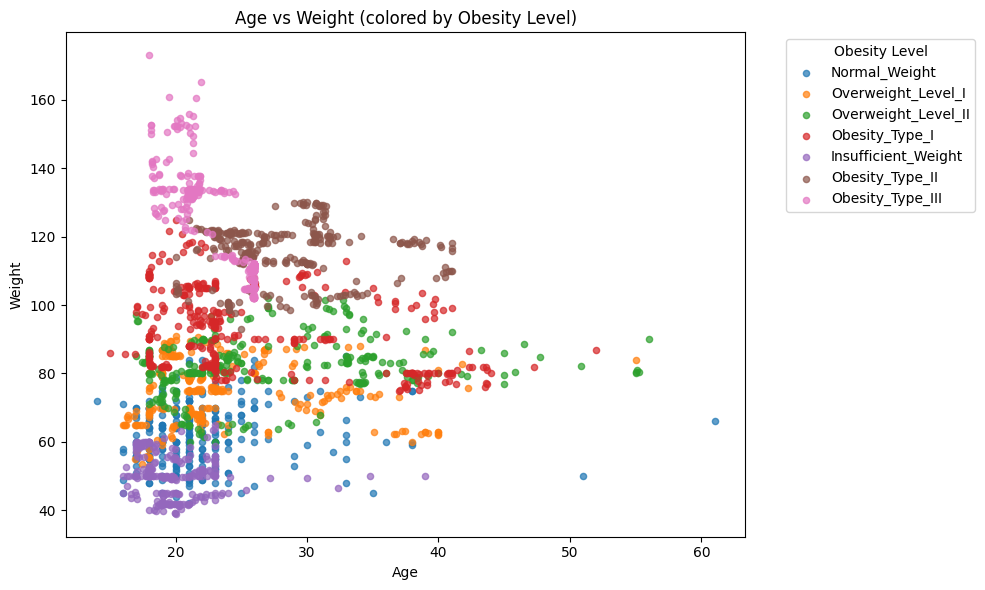

In [12]:
if "Age" in df.columns and "Weight" in df.columns and "NObeyesdad" in df.columns:
    plt.figure(figsize=(10, 6))

    # Get unique obesity levels and create color map
    obesity_levels = df["NObeyesdad"].unique()
    colors = plt.cm.tab10(range(len(obesity_levels)))

    for level, color in zip(obesity_levels, colors):
        mask = df["NObeyesdad"] == level
        plt.scatter(df.loc[mask, "Age"], df.loc[mask, "Weight"],
                   s=20, alpha=0.7, label=level, color=color)

    plt.title("Age vs Weight (colored by Obesity Level)")
    plt.xlabel("Age")
    plt.ylabel("Weight")
    plt.legend(title="Obesity Level", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print("Age/Weight/NObeyesdad columns not found in this CSV.")

# Does family history with overweight affect obesity type?

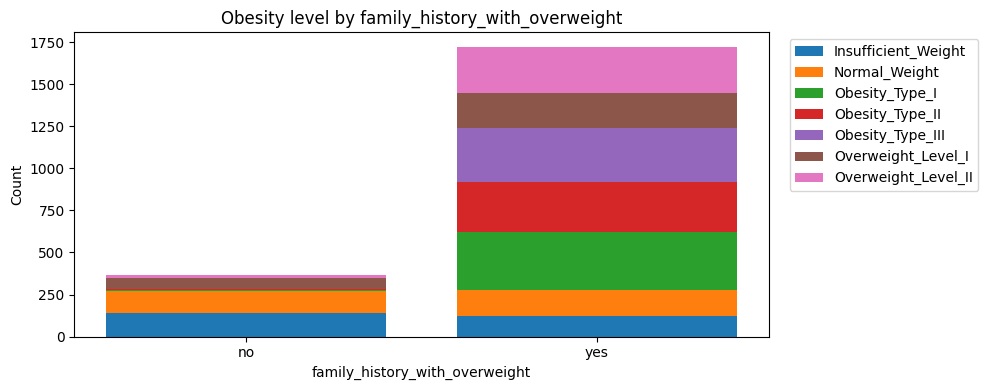

In [13]:
if "family_history_with_overweight" in df.columns:
    # Group counts by family history
    pivot = pd.crosstab(df["family_history_with_overweight"].astype(str), df[TARGET])
    plt.figure(figsize=(10,4))
    # stacked bars
    bottom = np.zeros(len(pivot.index))
    for cls in pivot.columns:
        plt.bar(pivot.index, pivot[cls].values, bottom=bottom, label=cls)
        bottom += pivot[cls].values
    plt.title("Obesity level by family_history_with_overweight")
    plt.xlabel("family_history_with_overweight")
    plt.ylabel("Count")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("Column 'family_history_with_overweight' not found.")

# Does eating food between meals affect obesity type?

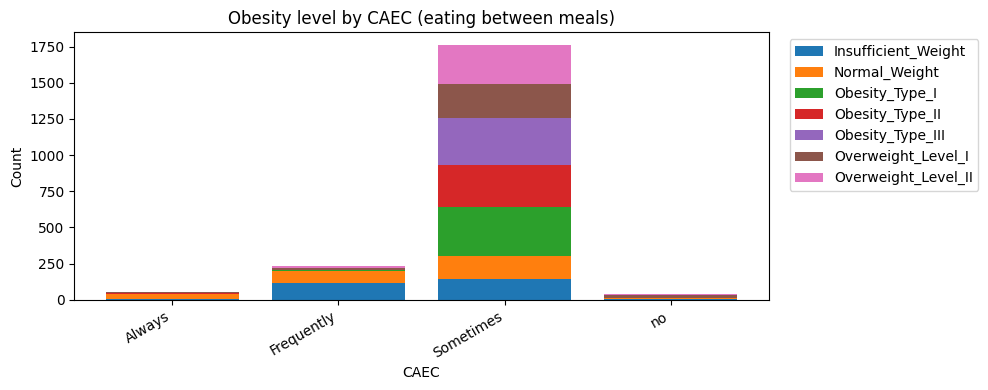

In [14]:
if "CAEC" in df.columns:
    pivot = pd.crosstab(df["CAEC"].astype(str), df[TARGET])
    plt.figure(figsize=(10,4))
    bottom = np.zeros(len(pivot.index))
    for cls in pivot.columns:
        plt.bar(pivot.index, pivot[cls].values, bottom=bottom, label=cls)
        bottom += pivot[cls].values
    plt.title("Obesity level by CAEC (eating between meals)")
    plt.xlabel("CAEC")
    plt.ylabel("Count")
    plt.xticks(rotation=30, ha="right")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("Column 'CAEC' not found.")

# Feature Engineering
We add **BMI** if Height and Weight exist.

Added BMI 


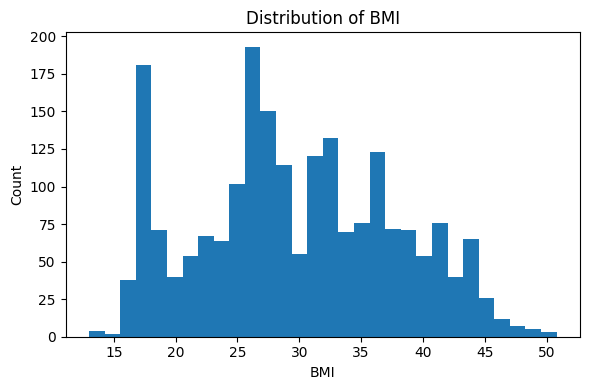

In [15]:
# =========================
# 4) Add BMI feature
# =========================
if "Height" in df.columns and "Weight" in df.columns:
    h = df["Height"].astype(float)
    # Heuristic: if height looks like centimeters, convert
    h_m = h / 100.0 if h.median() > 3.0 else h
    df["BMI"] = df["Weight"].astype(float) / (h_m ** 2)
    print("Added BMI ")
    hist_plot(df["BMI"], "Distribution of BMI")
else:
    print("Height/Weight missing; skipping BMI.")

# Correlation Matrix Heatmap (with values)

To match common “Kaggle-style” notebooks, we build a correlation heatmap **with values shown inside each cell**.

Important notes:
- Correlation requires numeric values.
- For this visualization **only**, we temporarily convert categorical columns (e.g., Gender, CAEC, MTRANS) to numeric codes.
- This does **not** affect the modeling pipeline (which still uses One-Hot Encoding + Scaling).

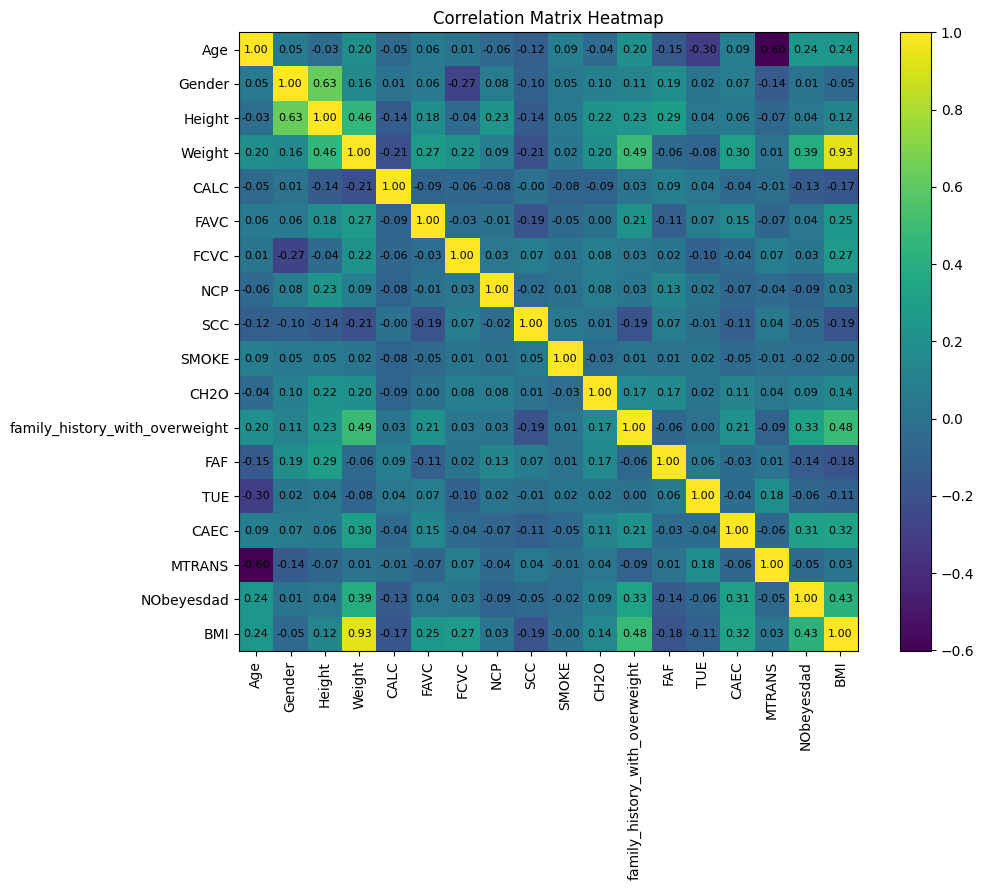

In [16]:
# =========================
# Correlation Matrix Heatmap (Annotated)
# - Converts categorical columns to codes for visualization only
# =========================
import numpy as np
import matplotlib.pyplot as plt

# Copy to avoid changing the original df used for modeling
corr_df = df.copy()

# Encode categorical columns as integer codes (visualization only)
for col in corr_df.columns:
    if corr_df[col].dtype == "object":
        corr_df[col] = corr_df[col].astype("category").cat.codes

# Ensure target is numeric codes too (if not already)
if TARGET in corr_df.columns and corr_df[TARGET].dtype == "object":
    corr_df[TARGET] = corr_df[TARGET].astype("category").cat.codes

# Compute correlation
corr = corr_df.corr(numeric_only=True)

# Plot heatmap with annotations
plt.figure(figsize=(12, 9))
im = plt.imshow(corr.values, interpolation="nearest")

plt.title("Correlation Matrix Heatmap")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

# Add numbers in each cell (rounded to 2 decimals)
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        plt.text(
            j, i,
            f"{corr.values[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## 5) Train/Test split + Preprocessing

We auto-detect:
- categorical columns (`object`)
- numeric columns (`int/float`)

Preprocessing:
- numeric → `StandardScaler`
- categorical → `OneHotEncoder(handle_unknown="ignore")`

In [17]:
X = df.drop(columns=[TARGET])
y = df[TARGET].astype(str)

cat_cols = [c for c in X.columns if X[c].dtype == "object"]
num_cols = [c for c in X.columns if c not in cat_cols]

print("Categorical columns:", cat_cols)
print("Numeric columns:", num_cols)

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ],
    remainder="drop"
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Categorical columns: ['Gender', 'CALC', 'FAVC', 'SCC', 'SMOKE', 'family_history_with_overweight', 'CAEC', 'MTRANS']
Numeric columns: ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE', 'BMI']
Train shape: (1669, 17) Test shape: (418, 17)


In [18]:
# Helper: GaussianNB needs dense arrays after one-hot encoding
class ToDense(BaseEstimator, TransformerMixin):
    """Convert sparse matrix to dense for models that require dense input."""
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return X.toarray() if hasattr(X, "toarray") else X

# Modeling (Required Models)
We train:
- **Gaussian Naive Bayes**
- **Logistic Regression**
- **SVM (LinearSVC) calibrated** → enables `predict_proba()` for Streamlit

In [19]:
# =========================
# 6) Define required models
# =========================
pipe_nb = Pipeline([
    ("prep", preprocess),
    ("dense", ToDense()),
    ("clf", GaussianNB())
])

pipe_lr = Pipeline([
    ("prep", preprocess),
    ("clf", LogisticRegression(max_iter=500, solver="lbfgs"))
])

svm_base = Pipeline([
    ("prep", preprocess),
    ("clf", LinearSVC())
])

# Calibrate to get probabilities
pipe_svm = CalibratedClassifierCV(estimator=svm_base, method="sigmoid", cv=3)

models_required = {
    "GaussianNB": pipe_nb,
    "LogisticRegression": pipe_lr,
    "LinearSVM_Calibrated": pipe_svm
}

# Modeling (Optional Extra Models)
These are optional but make your notebook look more “complete” like the examples:
- Decision Tree
- Random Forest
- AdaBoost
- Voting Classifier (ensemble)

In [20]:
# Optional models
pipe_dt = Pipeline([
    ("prep", preprocess),
    ("clf", DecisionTreeClassifier(random_state=42))
])

pipe_rf = Pipeline([
    ("prep", preprocess),
    ("clf", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

pipe_ada = Pipeline([
    ("prep", preprocess),
    ("clf", AdaBoostClassifier(random_state=42))
])

# Voting: combine LR + RF + calibrated SVM probabilities (soft vote)
# Note: For soft voting, all estimators need predict_proba; we use calibrated SVM.
pipe_vote = VotingClassifier(
    estimators=[
        ("lr", pipe_lr),
        ("rf", pipe_rf),
        ("svm", pipe_svm)
    ],
    voting="soft"
)

models_optional = {
    "DecisionTree": pipe_dt,
    "RandomForest": pipe_rf,
    "AdaBoost": pipe_ada,
    "VotingClassifier": pipe_vote
}

# Train + Evaluate
We report:
- Accuracy
- Macro F1 (best for multi-class imbalance)
- Classification report

In [21]:
def evaluate_model(name, model, X_te, y_te):
    """Evaluate a fitted model and return metrics + predictions."""
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    f1m = f1_score(y_te, y_pred, average="macro")
    return acc, f1m, y_pred

def train_and_compare(model_dict):
    results = []
    fitted = {}
    for name, model in model_dict.items():
        print("\n==============================")
        print("Training:", name)
        model.fit(X_train, y_train)
        fitted[name] = model

        acc, f1m, y_pred = evaluate_model(name, model, X_test, y_test)
        results.append((name, acc, f1m))
        print(f"Accuracy: {acc:.4f}")
        print(f"Macro F1: {f1m:.4f}")
        print(classification_report(y_test, y_pred))
    res_df = pd.DataFrame(results, columns=["Model", "Accuracy", "MacroF1"]).sort_values("MacroF1", ascending=False)
    return res_df, fitted

# Train required models
res_req, fitted_req = train_and_compare(models_required)
display(res_req)


Training: GaussianNB
Accuracy: 0.6364
Macro F1: 0.6120
                     precision    recall  f1-score   support

Insufficient_Weight       0.71      0.96      0.82        53
      Normal_Weight       0.61      0.30      0.40        57
     Obesity_Type_I       0.88      0.51      0.65        70
    Obesity_Type_II       0.42      0.95      0.58        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.55      0.49      0.52        55
Overweight_Level_II       0.52      0.24      0.33        58

           accuracy                           0.64       418
          macro avg       0.67      0.63      0.61       418
       weighted avg       0.68      0.64      0.62       418


Training: LogisticRegression
Accuracy: 0.9258
Macro F1: 0.9230
                     precision    recall  f1-score   support

Insufficient_Weight       0.95      1.00      0.97        53
      Normal_Weight       0.89      0.86      0.88        57
     Obesity_Type_I   

,Model,Accuracy,MacroF1
1,LogisticRegression,0.925837,0.923014
2,LinearSVM_Calibrated,0.782297,0.771770
0,GaussianNB,0.636364,0.612031


In [22]:
# Train optional models (you can skip this cell if you want)
res_opt, fitted_opt = train_and_compare(models_optional)
display(res_opt)


Training: DecisionTree
Accuracy: 0.9689
Macro F1: 0.9681
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.98      0.99        53
      Normal_Weight       0.97      1.00      0.98        57
     Obesity_Type_I       0.97      0.99      0.98        70
    Obesity_Type_II       0.97      0.98      0.98        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.94      0.91      0.93        55
Overweight_Level_II       0.93      0.93      0.93        58

           accuracy                           0.97       418
          macro avg       0.97      0.97      0.97       418
       weighted avg       0.97      0.97      0.97       418


Training: RandomForest
Accuracy: 0.9785
Macro F1: 0.9776
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.98      0.99        53
      Normal_Weight       0.89      1.00      0.94        57
     Obesity_Type_I       

,Model,Accuracy,MacroF1
1,RandomForest,0.978469,0.977558
0,DecisionTree,0.968900,0.968053
3,VotingClassifier,0.940191,0.938464
2,AdaBoost,0.708134,0.657131


## Select best model (from required + optional)
We choose the model with the highest **Macro F1**.

In [23]:
# Combine results and pick best
all_results = pd.concat([res_req, res_opt], ignore_index=True)
all_results = all_results.sort_values("MacroF1", ascending=False).reset_index(drop=True)
display(all_results)

best_name = all_results.loc[0, "Model"]

# Find the fitted model by name
best_model = None
if best_name in fitted_req:
    best_model = fitted_req[best_name]
elif best_name in fitted_opt:
    best_model = fitted_opt[best_name]
else:
    raise RuntimeError("Best model not found in fitted models dicts.")

print("Best model:", best_name)

,Model,Accuracy,MacroF1
0,RandomForest,0.978469,0.977558
1,DecisionTree,0.968900,0.968053
2,VotingClassifier,0.940191,0.938464
3,LogisticRegression,0.925837,0.923014
4,LinearSVM_Calibrated,0.782297,0.771770
5,AdaBoost,0.708134,0.657131
6,GaussianNB,0.636364,0.612031


Best model: RandomForest


# Confusion Matrix (Best Model)

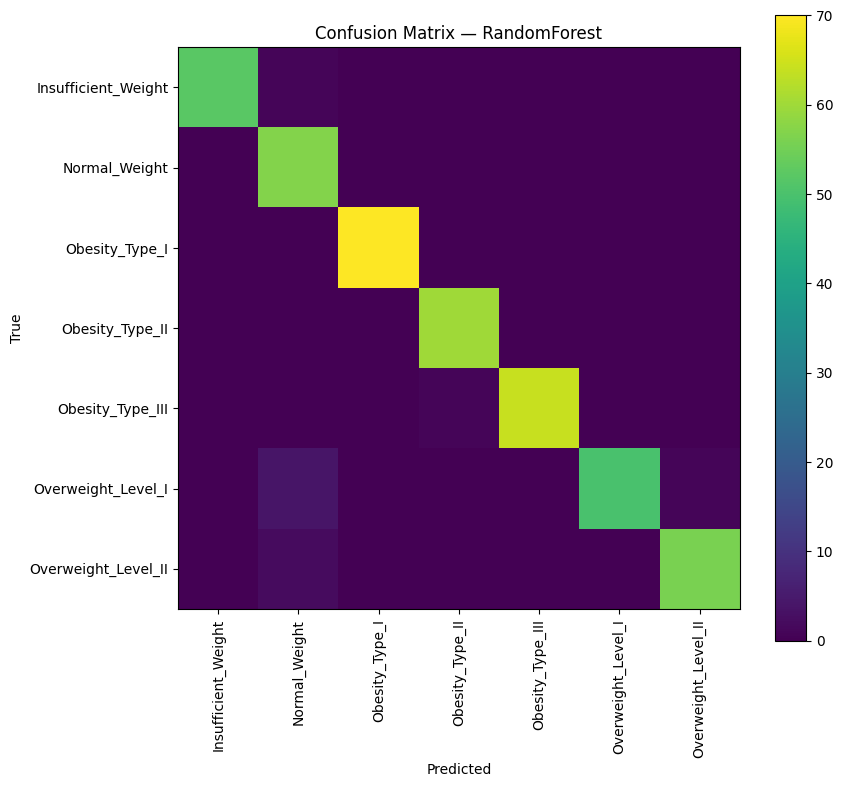

In [24]:
y_pred_best = best_model.predict(X_test)
labels = np.unique(y)

cm = confusion_matrix(y_test, y_pred_best, labels=labels)

plt.figure(figsize=(9, 8))
plt.imshow(cm, interpolation="nearest")
plt.title(f"Confusion Matrix — {best_name}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(np.arange(len(labels)), labels, rotation=90)
plt.yticks(np.arange(len(labels)), labels)
plt.colorbar()
plt.tight_layout()
plt.show()

# Example Prediction + Top‑5 Probabilities
Works because the best model is likely LR/RF/Voting or a **calibrated** SVM.

In [25]:
def topk_predictions(model, row_dict, k=5):
    """Predict top-k classes from a single input row dict."""
    x_in = pd.DataFrame([row_dict])
    probs = model.predict_proba(x_in)[0]
    classes = model.classes_
    top_idx = np.argsort(probs)[::-1][:k]
    return [(classes[i], float(probs[i])) for i in top_idx]

# Build a safe sample input (median/mode)
sample = {}
for c in num_cols:
    sample[c] = float(df[c].median())
for c in cat_cols:
    sample[c] = str(df[c].mode().iloc[0])

print("Sample input:", sample)
print("\nTop-5 predicted classes:")
for cls, p in topk_predictions(best_model, sample, k=5):
    print(f"{cls}: {p:.3f}")

Sample input: {'Age': 22.847618, 'Height': 1.701584, 'Weight': 83.1011, 'FCVC': 2.396265, 'NCP': 3.0, 'CH2O': 2.0, 'FAF': 1.0, 'TUE': 0.630866, 'BMI': 28.89622426303332, 'Gender': 'Male', 'CALC': 'Sometimes', 'FAVC': 'yes', 'SCC': 'no', 'SMOKE': 'no', 'family_history_with_overweight': 'yes', 'CAEC': 'Sometimes', 'MTRANS': 'Public_Transportation'}

Top-5 predicted classes:
Overweight_Level_II: 0.800
Overweight_Level_I: 0.143
Obesity_Type_I: 0.050
Normal_Weight: 0.003
Obesity_Type_II: 0.003


# Save model for Streamlit
We save:
- `obesity_best_model.joblib` (full pipeline)
- `schema.json` (to build Streamlit inputs automatically)

In [26]:
ART_DIR = "/content/artifacts"
os.makedirs(ART_DIR, exist_ok=True)

MODEL_PATH = os.path.join(ART_DIR, "obesity_best_model.joblib")
SCHEMA_PATH = os.path.join(ART_DIR, "schema.json")

joblib.dump(best_model, MODEL_PATH)

schema = {
    "target": TARGET,
    "recommended_model": best_name,
    "classes": labels.tolist(),
    "numeric_features": {},
    "categorical_features": {}
}

for c in num_cols:
    schema["numeric_features"][c] = {
        "min": float(df[c].min()),
        "max": float(df[c].max()),
        "median": float(df[c].median())
    }

for c in cat_cols:
    schema["categorical_features"][c] = {
        "options": sorted(df[c].astype(str).unique().tolist()),
        "default": str(df[c].mode().iloc[0])
    }

with open(SCHEMA_PATH, "w", encoding="utf-8") as f:
    json.dump(schema, f, indent=2)

print("Saved model:", MODEL_PATH)
print("Saved schema:", SCHEMA_PATH)

Saved model: /content/artifacts/obesity_best_model.joblib
Saved schema: /content/artifacts/schema.json


In [27]:
# Download artifacts to your computer
from google.colab import files
files.download(MODEL_PATH)
files.download(SCHEMA_PATH)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# This is New Plots Need to Add

In [37]:
# =========================
# Variables used in the analysis (Python version of the R tribble + kable)
# - Creates the same table with the same columns and rows
# - Shows it nicely inside a notebook with a caption
# =========================

import pandas as pd
from IPython.display import display

# Build the table (same content as your screenshot)
var_tbl = pd.DataFrame(
    [
        ["Age", "Age (years)", "Quantitative", "numeric"],
        ["BMI", "Body-mass index (Weight / Height²) — derived", "Quantitative", "numeric, kg/m²"],
        ["FAF", "Days/week with physical activity", "Ordered categorical", "0 = None, 1 = 1–2 d, 2 = 2–4 d, 3 = 4–5 d"],
        ["TUE", "Daily tech-device use", "Ordered categorical", "0–2 h / 3–5 h / >5 h"],
        ["FCVC", "Vegetable frequency in meals", "Ordered categorical", "1 = Rarely, 2 = Sometimes, 3 = Always"],
        ["FAVC", "Eat high-calorie food frequently?", "Binary categorical", "no / yes"],
        ["CH2O", "Daily water intake", "Ordered categorical", "1 = <1 L, 2 = 1–2 L, 3 = >2 L"],
        ["Gender", "Self-reported sex", "Binary categorical", "Female / Male"],
        ["MTRANS", "Primary transport mode", "Unordered categorical", "Automobile / Motorbike / Bike / Public Transportation / Walking"],
        ["NObeyesdad", "Expert-labelled obesity class", "Ordered categorical", "7 levels (Insufficient → Obesity III)"],
    ],
    columns=["Variable", "Description", "Type", "Levels / Units"],
)

# Display like kable(caption=..., booktabs=TRUE): use a captioned Styler
# Note: Jupyter/Colab will render this as a clean HTML table.
styled = (
    var_tbl.style
    .set_caption("Variables used in the analysis")
    .hide(axis="index")
)

display(styled)

Variable,Description,Type,Levels / Units
Age,Age (years),Quantitative,numeric
BMI,Body-mass index (Weight / Height²) — derived,Quantitative,"numeric, kg/m²"
FAF,Days/week with physical activity,Ordered categorical,"0 = None, 1 = 1–2 d, 2 = 2–4 d, 3 = 4–5 d"
TUE,Daily tech-device use,Ordered categorical,0–2 h / 3–5 h / >5 h
FCVC,Vegetable frequency in meals,Ordered categorical,"1 = Rarely, 2 = Sometimes, 3 = Always"
FAVC,Eat high-calorie food frequently?,Binary categorical,no / yes
CH2O,Daily water intake,Ordered categorical,"1 = <1 L, 2 = 1–2 L, 3 = >2 L"
Gender,Self-reported sex,Binary categorical,Female / Male
MTRANS,Primary transport mode,Unordered categorical,Automobile / Motorbike / Bike / Public Transportation / Walking
NObeyesdad,Expert-labelled obesity class,Ordered categorical,7 levels (Insufficient → Obesity III)


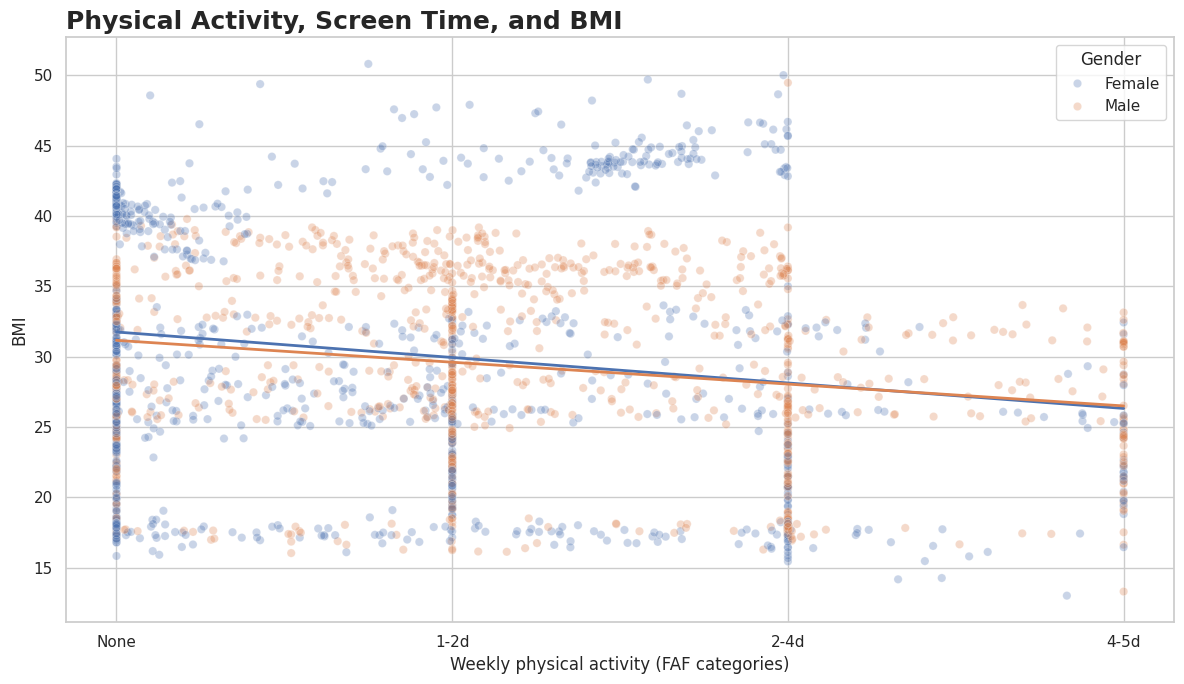

In [29]:
# ============================================
# Scatter (alpha=0.3) + linear fit lines per Gender
# X axis ticks: 0..3 with labels: None, 1-2d, 2-4d, 4-5d
# Labels: x="Weekly physical activity (FAF categories)", y="BMI"
# ============================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Assumes your notebook already has df with BMI computed and Gender/FAF present
# If BMI not created yet, uncomment:
# df["BMI"] = df["Weight"] / (df["Height"] ** 2)

# Keep only required rows (avoid NaNs breaking the plot)
plot_df = df.dropna(subset=["FAF", "BMI", "Gender"]).copy()

# Use a clean ggplot-like background
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 7))

# Scatter points (alpha=0.3), colored by Gender
sns.scatterplot(
    data=plot_df,
    x="FAF",
    y="BMI",
    hue="Gender",
    alpha=0.3,
)

# Add linear regression lines per Gender, no confidence interval (se=FALSE)
for gender in plot_df["Gender"].unique():
    sub = plot_df[plot_df["Gender"] == gender]
    if len(sub) >= 2:
        # Fit BMI = a + b*FAF
        b, a = np.polyfit(sub["FAF"].astype(float), sub["BMI"].astype(float), 1)
        xs = np.linspace(0, 3, 200)  # FAF categories range 0..3
        ys = a + b * xs
        plt.plot(xs, ys, linewidth=2)

# X axis ticks & labels
plt.xticks([0, 1, 2, 3], ["None", "1-2d", "2-4d", "4-5d"])

# Axis labels
plt.xlabel("Weekly physical activity (FAF categories)")
plt.ylabel("BMI")

# Optional: add  title style
plt.title("Physical Activity, Screen Time, and BMI", loc="left", fontsize=18, fontweight="bold")

plt.tight_layout()
plt.show()

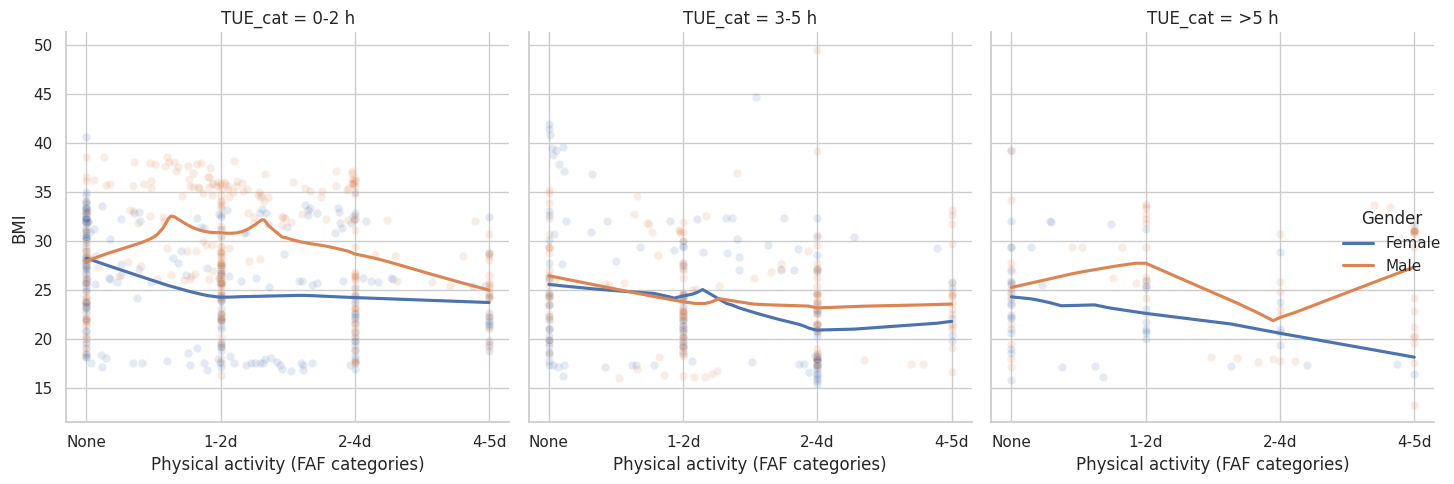

In [30]:
# ============================================
# - Force TUE_cat to be exactly: "0-2 h", "3-5 h", ">5 h"
# - Facet in 1 row (3 panels)
# - LOESS smooth + CI
# - FAF x-axis labels: None, 1-2d, 2-4d, 4-5d
# - Suppress the DeprecationWarning text
# ============================================

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)  # hide jupyter_client warning
warnings.filterwarnings("ignore")  # optional: hide all warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# ---------- 1) Recreate the correct TUE_cat (CMU uses 3 groups) ----------
# If you already had a wrong TUE_cat (Low/Mid/High/VeryHigh), overwrite it.
# CMU mapping: 0 -> 0-2 h, 1 -> 3-5 h, 2 -> >5 h
df["TUE"] = pd.to_numeric(df["TUE"], errors="coerce")

tue_map = {0: "0-2 h", 1: "3-5 h", 2: ">5 h"}
df["TUE_cat"] = df["TUE"].map(tue_map)

# Make facet order fixed (left-to-right)
df["TUE_cat"] = pd.Categorical(df["TUE_cat"], categories=["0-2 h", "3-5 h", ">5 h"], ordered=True)

# ---------- 2) Ensure BMI exists ----------
# (Only computes if not already present)
if "BMI" not in df.columns:
    df["BMI"] = df["Weight"] / (df["Height"] ** 2)

# ---------- 3) Plot data ----------
plot_df = df.dropna(subset=["FAF", "BMI", "Gender", "TUE_cat"]).copy()
plot_df["FAF"] = pd.to_numeric(plot_df["FAF"], errors="coerce")

# ---------- 4) Faceted scatter + LOESS smooth with CI ----------
g = sns.FacetGrid(
    plot_df,
    col="TUE_cat",
    col_order=["0-2 h", "3-5 h", ">5 h"],
    hue="Gender",
    height=5,
    aspect=0.9,
    sharey=True
)

# Scatter points (alpha=.15)
g.map_dataframe(sns.scatterplot, x="FAF", y="BMI", alpha=0.15)

# LOESS curve with CI (se=TRUE)
# regplot(lowess=True) draws a smooth curve and CI band
g.map_dataframe(
    sns.regplot,
    x="FAF",
    y="BMI",
    scatter=False,
    lowess=True,
    ci=95
)

# Match x-axis ticks/labels exactly
for ax in g.axes.flatten():
    ax.set_xticks([0, 1, 2, 3])
    ax.set_xticklabels(["None", "1-2d", "2-4d", "4-5d"])
    ax.set_xlabel("Physical activity (FAF categories)")
    ax.set_ylabel("BMI")

g.add_legend(title="Gender")
plt.tight_layout()
plt.show()

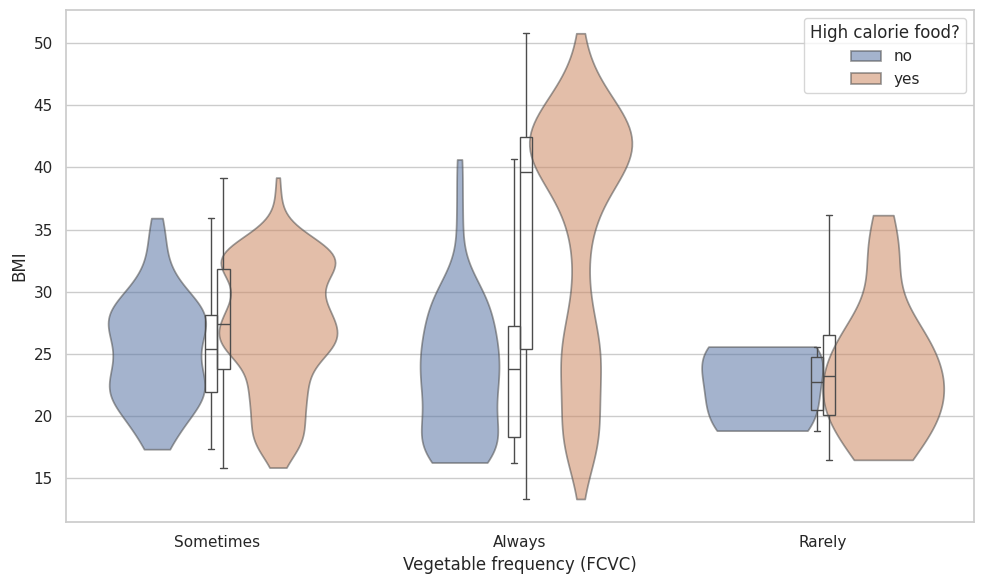

In [31]:
# ============================================
# RQ2: Vegetables, high-calorie food, and BMI
# Equivalent to:
# geom_violin(trim=FALSE, alpha=.55)
# geom_boxplot(width=.08, outlier.shape=NA)
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme(style="whitegrid")

# Ensure proper mapping for FCVC
fcvc_map = {1: "Rarely", 2: "Sometimes", 3: "Always"}
df["FCVC_label"] = pd.to_numeric(df["FCVC"], errors="coerce").map(fcvc_map)

# Keep only valid rows
rq2_df = df.dropna(subset=["BMI", "FCVC_label", "FAVC"]).copy()

plt.figure(figsize=(10, 6))

# Violin plot (trim=False equivalent, alpha=.55)
sns.violinplot(
    data=rq2_df,
    x="FCVC_label",
    y="BMI",
    hue="FAVC",
    cut=0,               # same idea as trim=FALSE
    alpha=0.55,
    inner=None
)

# Overlay boxplot (width=.08, hide outliers)
sns.boxplot(
    data=rq2_df,
    x="FCVC_label",
    y="BMI",
    hue="FAVC",
    width=0.08,
    showcaps=True,
    showfliers=False,
    boxprops={"facecolor": "none"}
)

plt.xlabel("Vegetable frequency (FCVC)")
plt.ylabel("BMI")

# Fix legend duplication
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[:2], ["no", "yes"], title="High calorie food?")

plt.tight_layout()
plt.show()

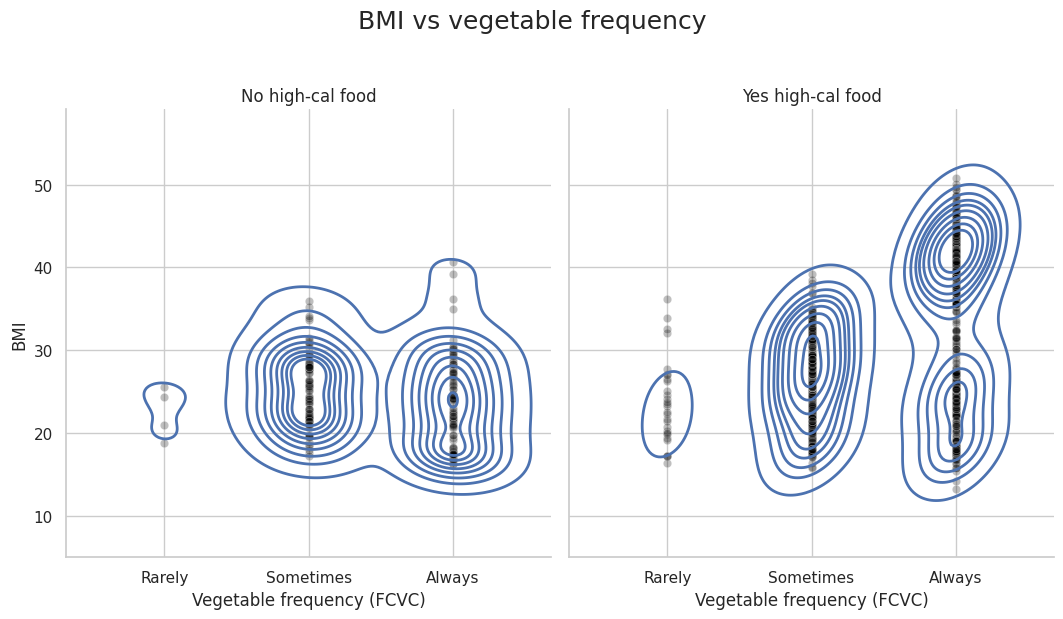

In [32]:
# ============================================
# BMI vs vegetable frequency
# Equivalent to:
# facet_wrap(~FAVC)
# + geom_point()
# + stat_density_2d()
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme(style="whitegrid")

# Ensure correct FCVC labels
fcvc_map = {1: "Rarely", 2: "Sometimes", 3: "Always"}
df["FCVC_label"] = pd.to_numeric(df["FCVC"], errors="coerce").map(fcvc_map)

plot_df = df.dropna(subset=["BMI", "FCVC_label", "FAVC"]).copy()

# Convert FCVC to numeric positions for density calculation
fcvc_numeric = {"Rarely": 0, "Sometimes": 1, "Always": 2}
plot_df["FCVC_num"] = plot_df["FCVC_label"].map(fcvc_numeric)

# Create 2 panels (No / Yes high-cal food)
g = sns.FacetGrid(
    plot_df,
    col="FAVC",
    col_order=["no", "yes"],
    height=6,
    aspect=0.9,
    sharey=True
)

# Scatter points
g.map_dataframe(
    sns.scatterplot,
    x="FCVC_num",
    y="BMI",
    color="black",
    alpha=0.25
)

# Density contours (equivalent to stat_density_2d)
g.map_dataframe(
    sns.kdeplot,
    x="FCVC_num",
    y="BMI",
    levels=10,
    fill=False,
    linewidths=2
)

# Fix x-axis labels
for ax in g.axes.flatten():
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(["Rarely", "Sometimes", "Always"])
    ax.set_xlabel("Vegetable frequency (FCVC)")
    ax.set_ylabel("BMI")

# Custom panel titles
g.axes[0, 0].set_title("No high-cal food")
g.axes[0, 1].set_title("Yes high-cal food")

plt.suptitle("BMI vs vegetable frequency", fontsize=18, y=1.03)
plt.tight_layout()
plt.show()

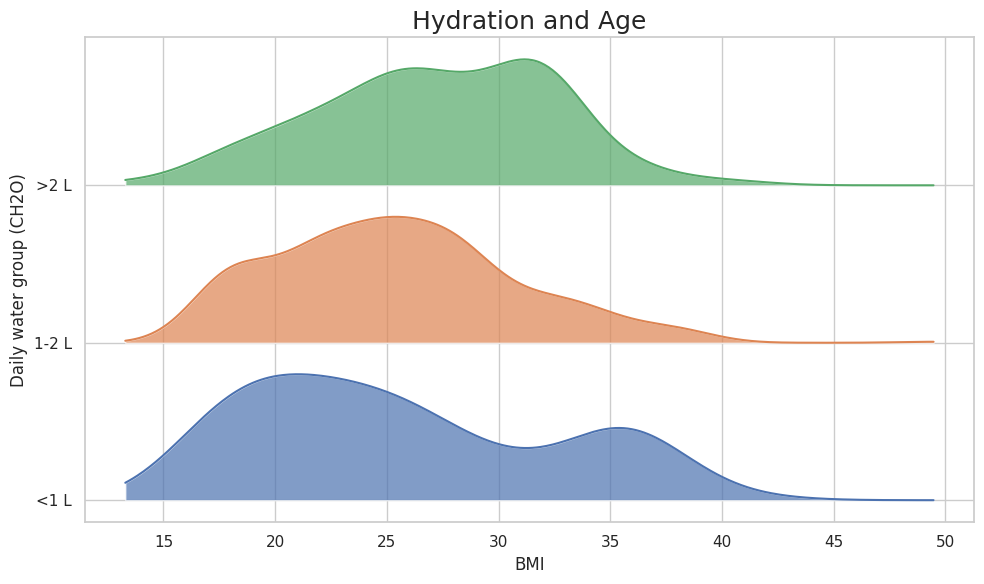

In [33]:
# ============================================
#Hydration and Age
# Equivalent to:
# geom_density_ridges(scale=1.1, alpha=.7)
# ============================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import gaussian_kde

sns.set_theme(style="whitegrid")

# Make sure BMI exists
if "BMI" not in df.columns:
    df["BMI"] = df["Weight"] / (df["Height"]**2)

# Map CH2O labels exactly like R
ch2o_map = {1: "<1 L", 2: "1-2 L", 3: ">2 L"}
df["CH2O_label"] = pd.to_numeric(df["CH2O"], errors="coerce").map(ch2o_map)

# Order categories bottom to top (same visual as screenshot)
order = ["<1 L", "1-2 L", ">2 L"]
plot_df = df.dropna(subset=["BMI", "CH2O_label"])
plot_df = plot_df[plot_df["CH2O_label"].isin(order)]

# Create ridgeline
plt.figure(figsize=(10, 6))

y_positions = np.arange(len(order))
x_vals = np.linspace(plot_df["BMI"].min(), plot_df["BMI"].max(), 400)

for i, level in enumerate(order):
    subset = plot_df[plot_df["CH2O_label"] == level]["BMI"]

    if len(subset) > 5:
        kde = gaussian_kde(subset)
        density = kde(x_vals)

        # Scale density height
        density = density / density.max() * 0.8

        plt.fill_between(
            x_vals,
            y_positions[i],
            y_positions[i] + density,
            alpha=0.7
        )

        plt.plot(
            x_vals,
            y_positions[i] + density,
            linewidth=1.5
        )

# Formatting
plt.yticks(y_positions, order)
plt.xlabel("BMI")
plt.ylabel("Daily water group (CH2O)")
plt.title("Hydration and Age", fontsize=18)

plt.tight_layout()
plt.show()

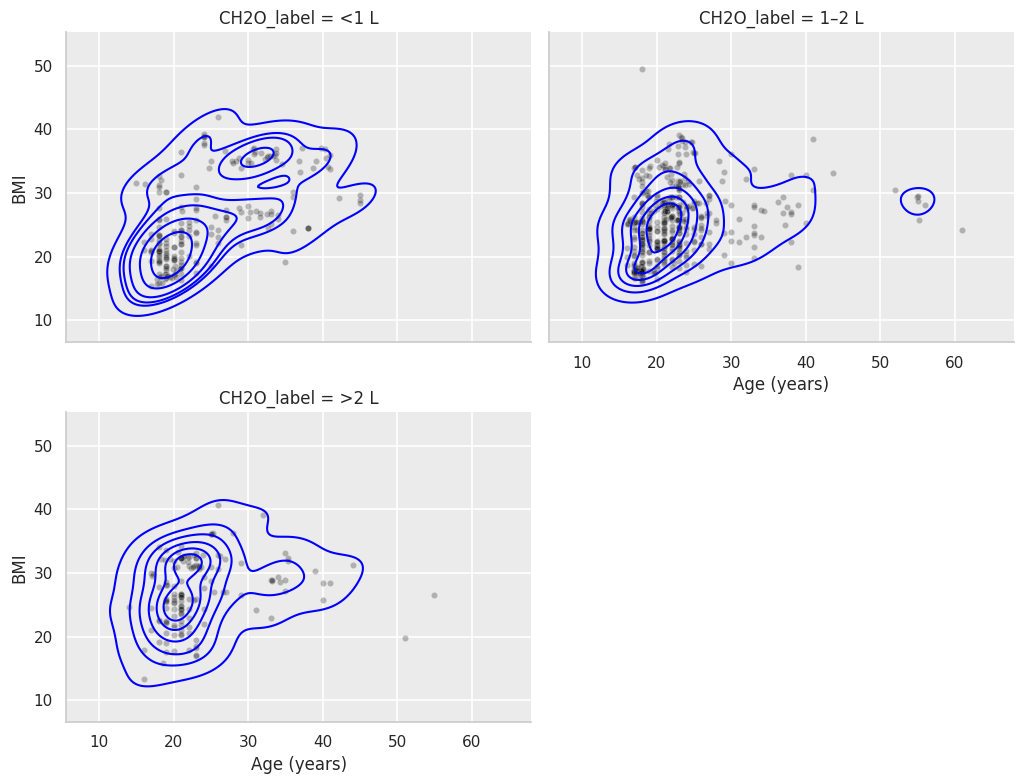

In [34]:
# ============================================
# RQ3: Hydration and Age (NO NA PANEL)
# - 3 panels: "<1 L", "1–2 L", ">2 L"
# - 2 columns layout
# - black scatter points
# - blue contour lines
# - ggplot-style grey panels
# ============================================

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Ensure BMI exists
if "BMI" not in df.columns:
    df["BMI"] = df["Weight"] / (df["Height"] ** 2)

# Clean CH2O and keep ONLY 1,2,3
tmp = df.copy()
tmp["CH2O_num"] = pd.to_numeric(tmp["CH2O"], errors="coerce")

tmp = tmp[tmp["CH2O_num"].isin([1, 2, 3])].copy()

label_map = {1: "<1 L", 2: "1–2 L", 3: ">2 L"}
tmp["CH2O_label"] = tmp["CH2O_num"].map(label_map)

order = ["<1 L", "1–2 L", ">2 L"]
tmp["CH2O_label"] = pd.Categorical(tmp["CH2O_label"], categories=order, ordered=True)

plot_df = tmp.dropna(subset=["Age", "BMI"])

# FacetGrid (3 panels)
g = sns.FacetGrid(
    plot_df,
    col="CH2O_label",
    col_order=order,
    col_wrap=2,        # 2 columns layout
    height=4,
    aspect=1.3,
    sharex=True,
    sharey=True
)

# Scatter points
g.map_dataframe(
    sns.scatterplot,
    x="Age",
    y="BMI",
    color="black",
    alpha=0.25,
    s=20
)

# 2D density contours
g.map_dataframe(
    sns.kdeplot,
    x="Age",
    y="BMI",
    levels=7,
    color="blue",
    linewidths=1.5,
    fill=False
)

# ggplot-like grey panels
for ax in g.axes.flatten():
    ax.set_facecolor("#EBEBEB")
    ax.grid(True, color="white", linewidth=1.2)
    ax.set_axisbelow(True)

g.set_axis_labels("Age (years)", "BMI")

plt.tight_layout()
plt.show()

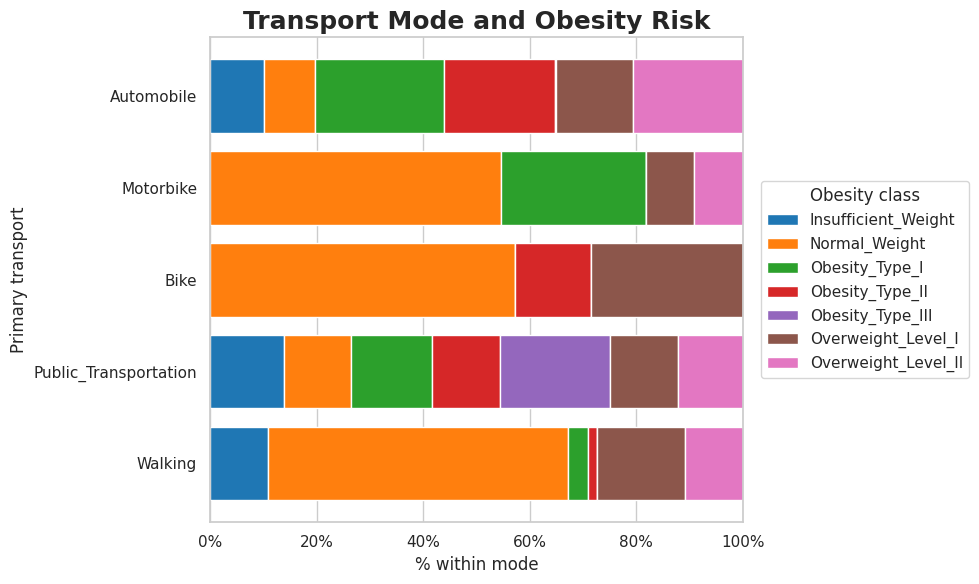

In [35]:
# ============================================
# Transport Mode and Obesity Risk
# FIXED VERSION (no duplicate column error)
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

sns.set_theme(style="whitegrid")

plot_df = df.dropna(subset=["MTRANS", "NObeyesdad"]).copy()

# Compute proportions directly (cleaner method)
prop = (
    plot_df
    .groupby("MTRANS")["NObeyesdad"]
    .value_counts(normalize=True)
    .rename("prop")
    .reset_index()
)

# Pivot for stacked bars
pivot = prop.pivot(index="MTRANS", columns="NObeyesdad", values="prop").fillna(0)

# Optional: reorder rows to match screenshot
transport_order = ["Walking", "Public_Transportation", "Bike", "Motorbike", "Automobile"]
pivot = pivot.reindex([t for t in transport_order if t in pivot.index])

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

bottom = None
colors = sns.color_palette("tab10", n_colors=len(pivot.columns))

for i, col in enumerate(pivot.columns):
    ax.barh(
        pivot.index,
        pivot[col],
        left=bottom,
        label=col,
        color=colors[i]
    )
    bottom = pivot[col] if bottom is None else bottom + pivot[col]

# Format as percent
ax.xaxis.set_major_formatter(PercentFormatter(1.0))

ax.set_xlabel("% within mode")
ax.set_ylabel("Primary transport")
ax.set_title("Transport Mode and Obesity Risk", fontsize=18, weight="bold")

ax.legend(title="Obesity class", bbox_to_anchor=(1.02, 0.5), loc="center left")

plt.tight_layout()
plt.show()

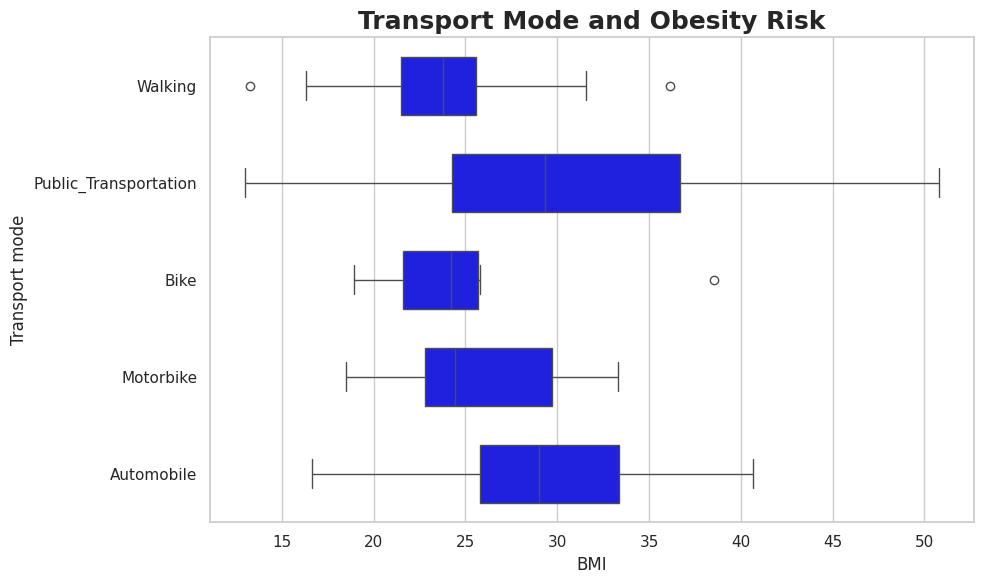

In [36]:
# ============================================
# Transport Mode and BMI (Boxplot)
# Equivalent to:
# geom_boxplot() + coord_flip()
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Optional: enforce order like screenshot
order = ["Walking", "Public_Transportation", "Bike", "Motorbike", "Automobile"]

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="BMI",
    y="MTRANS",
    order=[o for o in order if o in df["MTRANS"].unique()],
    color="blue",
    width=0.6
)

plt.xlabel("BMI")
plt.ylabel("Transport mode")
plt.title("Transport Mode and Obesity Risk", fontsize=18, weight="bold")

plt.tight_layout()
plt.show()